Notebook Overview

This is a 4th attempt to see if data Augementation Improves Models ability to classify images. On this Epoch i will use two models, one where the data has been augmented and a non-augmented  and compare which accuracy is better. Ill be using 50 epochs for each Process and also same number of epochs. This Procedure involves Normalizing the augmented parameters which from the prevoius dataset were non Augmented

# Test 1
Non-Augmenteted data Model on 50 epochs and steps_per epoch of 1000 meaning batch_size will be 50

In [1]:
#Mounting drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import tensorflow as tf

In [3]:
#Loading Cifar dataset
(train_images,train_labels),(test_images,test_labels)=tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [4]:
#Normalize Dataset
train_images,test_images  = train_images/255.0,test_images/255.0

In [5]:
train_images.shape

(50000, 32, 32, 3)

In [6]:
# Defining shape of input data
shape = train_images[0].shape
print(shape)

(32, 32, 3)


In [7]:
#Building Model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(64,(3,3),activation='relu',input_shape= shape))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3),activation ='relu'))
model.add(Flatten())
model.add(Dense(64,activation = 'relu'))
model.add(Dense(10,activation = 'softmax'))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,898 (554.29 KB)

 Trainable params: 141,898 (554.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# compiling model
model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [9]:
training_model = model.fit(train_images,train_labels,epochs =50,steps_per_epoch= 1000,validation_data=(test_images,test_labels))

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 117s 114ms/step - accuracy: 0.3400 - loss: 1.7876 - val_accuracy: 0.5277 - val_loss: 1.2906
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 139s 111ms/step - accuracy: 0.5447 - loss: 1.2686 - val_accuracy: 0.6060 - val_loss: 1.1224
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 112ms/step - accuracy: 0.6204 - loss: 1.0768 - val_accuracy: 0.6329 - val_loss: 1.0481
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - accuracy: 0.6602 - loss: 0.9661 - val_accuracy: 0.6648 - val_loss: 0.9561
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 119s 119ms/step - accuracy: 0.6908 - loss: 0.8804 - val_accuracy: 0.6776 - val_loss: 0.9199
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 109s 109ms/step - accuracy: 0.7148 - loss: 0.8153 - val_accuracy: 0.6980 - val_loss: 0.8749
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 145s 113ms/step - accuracy: 0.7351 - loss: 0.7591 - val_accuracy: 0.7004 - val_loss: 0.8573
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 141s 111ms/step - ac

In [10]:
model.evaluate(test_images,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7032 - loss: 2.2295


[2.318490505218506, 0.6942999958992004]

In [12]:
# Saving History and model stats
import os
save_path = '/content/drive/MyDrive/ML_Project' #creating project folder in drive
if not os.path.exists(save_path):
    os.makedirs(save_path)
model.save(f'{save_path}/my_trained_model.keras')
import pandas as pd
hist_df = pd.DataFrame(training_model.history)
hist_df.to_csv(f'{save_path}/training_log.csv', index=False)


# Test 2
Augmented data model running on 50 epochs and batch size of 1000

In [13]:
#Loading Cifar dataset
(train_images,train_labels),(test_images,test_labels)=tf.keras.datasets.cifar10.load_data()

In [14]:
# Normalizing Data
train_images,test_images  = train_images/255.0,test_images/255.0

In [15]:
#Building Model
layers = tf.keras.layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

Aug_model = Sequential()
Aug_model.add(Conv2D(64,(3,3),activation='relu',input_shape= shape))
Aug_model.add(MaxPooling2D((2,2)))
Aug_model.add(Conv2D(64,(3,3),activation='relu'))
Aug_model.add(MaxPooling2D(2,2))
Aug_model.add(Conv2D(64,(3,3),activation ='relu'))
Aug_model.add(layers.Flatten())
Aug_model.add(layers.Dense(64,activation = 'relu'))
Aug_model.add(layers.Dense(10,activation = 'softmax'))
Aug_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,898 (554.29 KB)

 Trainable params: 141,898 (554.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rotation_range=40, # images will be randomly rotated by a degree of 40
width_shift_range=0.2,# Images will be randomly shifted horizontally by up to 20% of their total width.
height_shift_range=0.2,#img randomly shifted vertically
shear_range=0.2,# Images will be randomly sheared (tilted along an axis) by up to 20 degrees.
zoom_range=0.2, #Images will be randomly zoomed in by up to 20%
horizontal_flip=True, # randomly flipped
fill_mode='nearest')
'''
When transformations cause pixels to go outside the image boundaries (e.g., rotation, shift),
this specifies how to fill the newly created empty pixels (here, it fills them with the nearest pixel value).
'''




'\nWhen transformations cause pixels to go outside the image boundaries (e.g., rotation, shift),\nthis specifies how to fill the newly created empty pixels (here, it fills them with the nearest pixel value).\n'

In [17]:
'''
This iterator will be responsible for:
Taking the train_images and train_labels.
Dividing them into batches of 50 images (as specified by batch_size=50).
Applying the random data augmentations (rotations, shifts, flips, brightness changes, etc.) that you configured in your datagen object to each image within those batches.
Yielding (providing) these augmented batches of images and their corresponding labels whenever requested by the training loop.
'''
train_generator = datagen.flow(train_images,train_labels,batch_size =50)

In [18]:
#compiling model
Aug_model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [19]:
augmented_training_model = Aug_model.fit(train_generator,epochs = 50,steps_per_epoch= 1000,validation_data=(test_images,test_labels))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 144s 142ms/step - accuracy: 0.2509 - loss: 1.9931 - val_accuracy: 0.4356 - val_loss: 1.5253
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 138s 137ms/step - accuracy: 0.3878 - loss: 1.6720 - val_accuracy: 0.4995 - val_loss: 1.4065
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 139s 139ms/step - accuracy: 0.4359 - loss: 1.5579 - val_accuracy: 0.5336 - val_loss: 1.2971
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 140s 140ms/step - accuracy: 0.4692 - loss: 1.4760 - val_accuracy: 0.5222 - val_loss: 1.3505
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 140ms/step - accuracy: 0.4849 - loss: 1.4263 - val_accuracy: 0.5385 - val_loss: 1.2741
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 153s 151ms/step - accuracy: 0.5049 - loss: 1.3771 - val_accuracy: 0.5652 - val_loss: 1.2073
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 200s 150ms/step - accuracy: 0.5138 - loss: 1.3497 - val_accuracy: 0.5755 - val_loss: 1.2013
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 140s 140ms/step - ac

In [20]:
Aug_model.evaluate(test_images,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7136 - loss: 0.8348


[0.8340645432472229, 0.7145000100135803]

In [21]:
import os
save_path = '/content/drive/MyDrive/ML_Project' #creating project folder in drive
if not os.path.exists(save_path):
    os.makedirs(save_path)
Aug_model.save(f'{save_path}/aug1_trained_model.keras')
import pandas as pd
hist_df = pd.DataFrame(augmented_training_model.history)
hist_df.to_csv(f'{save_path}/aug1_training_log.csv', index=False)


# Visualizing Models Perfomance

In [1]:
# mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#loading histories csv into panda dataframes
import pandas as pd
non_aug_history = pd.read_csv('/content/drive/MyDrive/ML_Project/training_log.csv')
aug_history = pd.read_csv('/content/drive/MyDrive/ML_Project/aug1_training_log.csv')

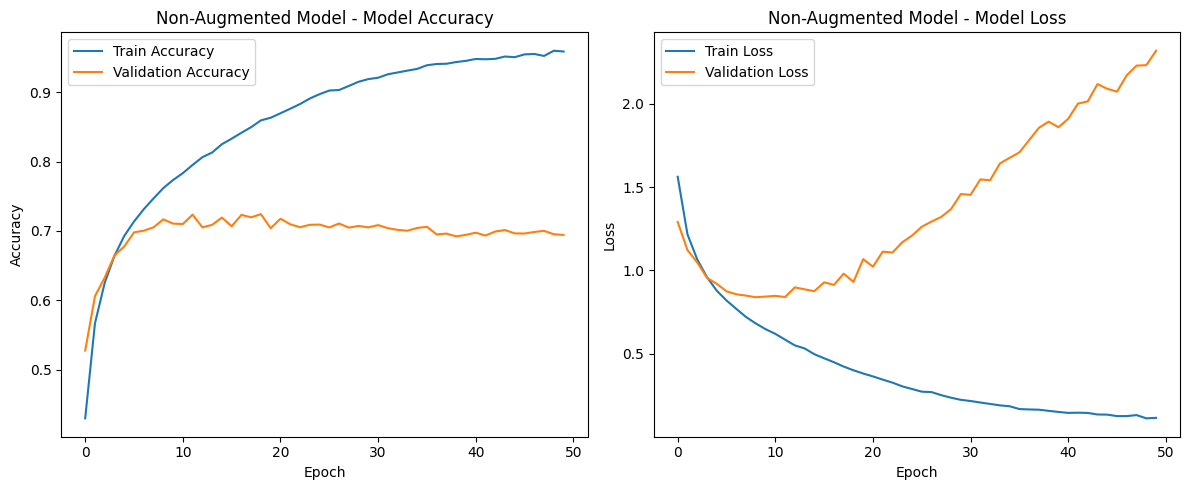

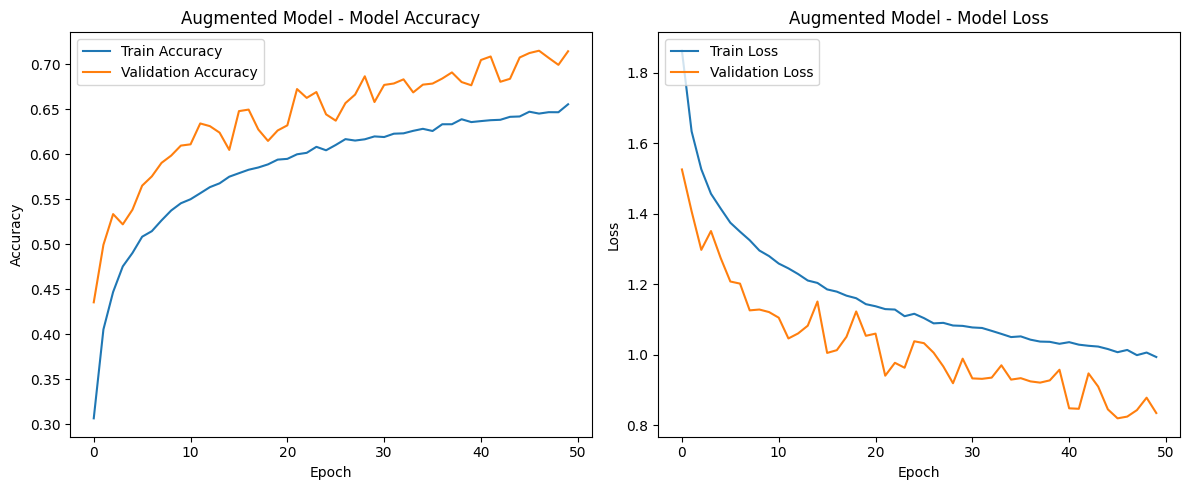

In [4]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Plot for Non-Augmented Model
plot_history(non_aug_history, 'Non-Augmented Model')

# Plot for Augmented Model
plot_history(aug_history, 'Augmented Model')